In [1]:
# Machine Learning Project
## Title: Daily Income Prediction for Bodaboda Riders in Tanzania

### Objective
#The objective of this project is to design, train, evaluate, and deploy a machine learning model
#that predicts the daily income of bodaboda riders in Tanzania based on working conditions and
#environmental factors.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


In [3]:
#disaplay working directory
cwd = os.getcwd()
print(cwd)

C:\Users\HP\Desktop\project


In [4]:
#import data file
df = pd.read_csv("bodaboda_income_dataset.csv")
print(df.corr(numeric_only=True))

                 hours_worked  number_of_trips  fuel_cost  daily_income
hours_worked         1.000000         0.605516   0.199422      0.637228
number_of_trips      0.605516         1.000000   0.137635      0.977977
fuel_cost            0.199422         0.137635   1.000000      0.010355
daily_income         0.637228         0.977977   0.010355      1.000000


In [5]:
print(df)

    hours_worked  number_of_trips  fuel_cost rainy_day road_condition  \
0             12               37      12777        No           Fair   
1              9               30       5197       Yes           Fair   
2             10               34      12125        No           Fair   
3             12               38       6930        No           Poor   
4              8               24      11287        No           Poor   
..           ...              ...        ...       ...            ...   
75             8               34       9496        No           Good   
76            11               24       9735       Yes           Poor   
77             6               24       9555        No           Poor   
78             9               40      14146       Yes           Poor   
79             7               24      13050       Yes           Fair   

   location_type  daily_income  
0          Rural      91481.65  
1          Urban      80600.10  
2          Urban      87

In [6]:
df.head(75)

,hours_worked,number_of_trips,fuel_cost,rainy_day,road_condition,location_type,daily_income
0,12,37,12777,No,Fair,Rural,91481.65
1,9,30,5197,Yes,Fair,Urban,80600.10
2,10,34,12125,No,Fair,Urban,87998.66
3,12,38,6930,No,Poor,Rural,98783.44
4,8,24,11287,No,Poor,Rural,53053.48
...,...,...,...,...,...,...,...
70,9,28,9911,No,Poor,Urban,70612.95
71,12,52,8987,No,Fair,Rural,131700.66
72,9,39,14719,No,Poor,Rural,88060.32
73,10,31,11015,No,Fair,Rural,75724.29


In [7]:
df.tail()

,hours_worked,number_of_trips,fuel_cost,rainy_day,road_condition,location_type,daily_income
75,8,34,9496,No,Good,Urban,88072.41
76,11,24,9735,Yes,Poor,Rural,50755.61
77,6,24,9555,No,Poor,Urban,57917.69
78,9,40,14146,Yes,Poor,Rural,86324.99
79,7,24,13050,Yes,Fair,Rural,50197.94


In [8]:
df.shape #dimensions

(80, 7)

In [9]:
df.dtypes #datatypes

hours_worked         int64
number_of_trips      int64
fuel_cost            int64
rainy_day           object
road_condition      object
location_type       object
daily_income       float64
dtype: object

In [10]:

df.info() #essential details

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hours_worked     80 non-null     int64  
 1   number_of_trips  80 non-null     int64  
 2   fuel_cost        80 non-null     int64  
 3   rainy_day        80 non-null     object 
 4   road_condition   80 non-null     object 
 5   location_type    80 non-null     object 
 6   daily_income     80 non-null     float64
dtypes: float64(1), int64(3), object(3)
memory usage: 4.5+ KB


In [11]:
df.isnull().sum() #sum of missing values in each column

hours_worked       0
number_of_trips    0
fuel_cost          0
rainy_day          0
road_condition     0
location_type      0
daily_income       0
dtype: int64

In [12]:
#Getting matrix for features(X for independent variable and Y for dependent variable)
X = df.iloc[:,:-1].values #all columns except the last column
Y = df.iloc[:, 6:7].values # the last column only 
#.values convert the df into numpy array 

In [13]:
print(X)

[[12 37 12777 'No' 'Fair' 'Rural']
 [9 30 5197 'Yes' 'Fair' 'Urban']
 [10 34 12125 'No' 'Fair' 'Urban']
 [12 38 6930 'No' 'Poor' 'Rural']
 [8 24 11287 'No' 'Poor' 'Rural']
 [10 33 13800 'No' 'Poor' 'Rural']
 [10 24 14339 'No' 'Good' 'Rural']
 [12 51 9282 'Yes' 'Fair' 'Rural']
 [7 25 7511 'Yes' 'Good' 'Urban']
 [8 28 14986 'No' 'Poor' 'Rural']
 [12 38 5659 'No' 'Fair' 'Urban']
 [8 28 7811 'Yes' 'Good' 'Urban']
 [8 27 12098 'Yes' 'Fair' 'Urban']
 [10 34 11546 'No' 'Good' 'Rural']
 [9 38 14561 'Yes' 'Fair' 'Urban']
 [8 34 6986 'No' 'Poor' 'Urban']
 [11 36 13338 'Yes' 'Poor' 'Rural']
 [10 41 7911 'No' 'Fair' 'Urban']
 [7 15 6734 'Yes' 'Good' 'Urban']
 [9 31 6843 'No' 'Poor' 'Rural']
 [11 22 13680 'Yes' 'Poor' 'Urban']
 [11 26 7976 'Yes' 'Poor' 'Urban']
 [7 24 6959 'No' 'Fair' 'Urban']
 [9 39 10759 'Yes' 'Fair' 'Rural']
 [10 23 11694 'No' 'Good' 'Rural']
 [6 21 7385 'Yes' 'Good' 'Rural']
 [9 21 9736 'No' 'Good' 'Urban']
 [7 16 6802 'Yes' 'Fair' 'Urban']
 [11 23 13155 'No' 'Fair' 'Rural']
 [

In [14]:
print(Y)

[[ 91481.65]
 [ 80600.1 ]
 [ 87998.66]
 [ 98783.44]
 [ 53053.48]
 [ 74293.56]
 [ 56330.43]
 [126922.36]
 [ 65741.14]
 [ 60604.96]
 [104337.54]
 [ 71886.87]
 [ 63584.44]
 [ 81552.93]
 [ 90604.45]
 [ 87368.96]
 [ 82507.32]
 [106652.16]
 [ 43098.38]
 [ 74185.2 ]
 [ 49462.65]
 [ 65787.02]
 [ 66967.92]
 [ 90680.87]
 [ 56600.15]
 [ 47839.16]
 [ 57628.88]
 [ 40439.18]
 [ 53421.12]
 [ 58121.9 ]
 [ 95901.46]
 [ 17654.3 ]
 [ 29355.23]
 [ 45529.94]
 [ 85161.36]
 [ 60363.41]
 [ 34857.51]
 [ 95294.47]
 [ 84275.9 ]
 [122996.6 ]
 [ 68608.56]
 [105128.8 ]
 [121659.71]
 [ 53816.99]
 [ 72637.04]
 [ 51125.98]
 [105028.5 ]
 [ 96236.9 ]
 [ 33293.06]
 [ 43116.21]
 [ 90811.69]
 [ 37389.08]
 [ 98681.11]
 [ 53841.58]
 [ 57603.86]
 [114847.89]
 [ 54782.02]
 [ 46811.98]
 [ 70622.5 ]
 [ 65906.87]
 [108174.11]
 [ 76151.1 ]
 [ 30179.37]
 [ 59406.22]
 [ 39785.84]
 [ 99112.82]
 [ 56428.52]
 [ 91174.51]
 [ 43098.04]
 [ 66864.23]
 [ 70612.95]
 [131700.66]
 [ 88060.32]
 [ 75724.29]
 [132271.76]
 [ 88072.41]
 [ 50755.61]

In [15]:
#Encoding Categorical data(Class Label)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
X[:,3] = label_encoder.fit_transform(X[:,3]) # labels on rainy_day

In [16]:
#Encoding categorical data(ordinal features)  <road_condition>
from sklearn.preprocessing import OrdinalEncoder
rank_order = [["Poor", "Fair", "Good"]]
ordinal_encoder = OrdinalEncoder(categories=rank_order)
X[:, 4:5] = ordinal_encoder.fit_transform(X[:, 4:5])  


In [17]:
#Encoding categorical data (nominal features) <location_type>
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder(handle_unknown='ignore')
encoder_X = onehot_encoder.fit_transform(X[:,5:6]).toarray()

In [18]:
import numpy as np
X = np.delete(X, 5, axis=1)

 #Add encoded columns
X = np.column_stack((encoder_X, X))

In [91]:
print(X)

[[1.0 0.0 12 37 12777 0 1.0]
 [0.0 1.0 9 30 5197 1 1.0]
 [0.0 1.0 10 34 12125 0 1.0]
 [1.0 0.0 12 38 6930 0 0.0]
 [1.0 0.0 8 24 11287 0 0.0]
 [1.0 0.0 10 33 13800 0 0.0]
 [1.0 0.0 10 24 14339 0 2.0]
 [1.0 0.0 12 51 9282 1 1.0]
 [0.0 1.0 7 25 7511 1 2.0]
 [1.0 0.0 8 28 14986 0 0.0]
 [0.0 1.0 12 38 5659 0 1.0]
 [0.0 1.0 8 28 7811 1 2.0]
 [0.0 1.0 8 27 12098 1 1.0]
 [1.0 0.0 10 34 11546 0 2.0]
 [0.0 1.0 9 38 14561 1 1.0]
 [0.0 1.0 8 34 6986 0 0.0]
 [1.0 0.0 11 36 13338 1 0.0]
 [0.0 1.0 10 41 7911 0 1.0]
 [0.0 1.0 7 15 6734 1 2.0]
 [1.0 0.0 9 31 6843 0 0.0]
 [0.0 1.0 11 22 13680 1 0.0]
 [0.0 1.0 11 26 7976 1 0.0]
 [0.0 1.0 7 24 6959 0 1.0]
 [1.0 0.0 9 39 10759 1 1.0]
 [1.0 0.0 10 23 11694 0 2.0]
 [1.0 0.0 6 21 7385 1 2.0]
 [0.0 1.0 9 21 9736 0 2.0]
 [0.0 1.0 7 16 6802 1 1.0]
 [1.0 0.0 11 23 13155 0 1.0]
 [0.0 1.0 10 23 13120 1 2.0]
 [0.0 1.0 9 36 11616 0 2.0]
 [1.0 0.0 6 12 10534 1 1.0]
 [1.0 0.0 6 12 9061 0 2.0]
 [0.0 1.0 8 16 5262 0 0.0]
 [0.0 1.0 8 34 11287 0 1.0]
 [0.0 1.0 12 24 13815 

In [119]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state=0)



In [120]:
print(X_train)

[[1.0 0.0 12 38 6930 0 0.0]
 [0.0 1.0 7 24 6959 0 1.0]
 [1.0 0.0 12 51 9282 1 1.0]
 [0.0 1.0 9 21 9736 0 2.0]
 [1.0 0.0 12 52 12400 1 0.0]
 [1.0 0.0 9 36 10423 0 1.0]
 [1.0 0.0 11 44 12158 1 1.0]
 [1.0 0.0 7 24 13050 1 1.0]
 [1.0 0.0 12 49 13445 1 1.0]
 [0.0 1.0 10 41 7911 0 1.0]
 [1.0 0.0 11 44 7961 1 1.0]
 [1.0 0.0 7 14 9433 0 1.0]
 [1.0 0.0 10 24 14339 0 2.0]
 [1.0 0.0 7 23 7557 0 2.0]
 [1.0 0.0 10 31 11015 0 1.0]
 [1.0 0.0 8 24 11287 0 0.0]
 [0.0 1.0 8 16 5262 0 0.0]
 [0.0 1.0 10 23 14637 1 1.0]
 [1.0 0.0 11 23 13155 0 1.0]
 [0.0 1.0 8 28 7811 1 2.0]
 [0.0 1.0 9 18 10592 1 2.0]
 [1.0 0.0 9 39 10759 1 1.0]
 [0.0 1.0 12 38 5659 0 1.0]
 [1.0 0.0 6 12 10534 1 1.0]
 [1.0 0.0 11 22 8170 0 1.0]
 [0.0 1.0 7 30 9973 0 1.0]
 [0.0 1.0 9 30 5197 1 1.0]
 [1.0 0.0 6 12 9061 0 2.0]
 [0.0 1.0 8 34 9496 0 2.0]
 [0.0 1.0 9 38 14561 1 1.0]
 [1.0 0.0 6 27 9199 1 0.0]
 [1.0 0.0 9 31 6843 0 0.0]
 [0.0 1.0 10 23 13120 1 2.0]
 [0.0 1.0 8 19 11197 1 0.0]
 [1.0 0.0 10 23 11694 0 2.0]
 [0.0 1.0 12 24 13815 1

In [121]:
print(X_test)

[[1.0 0.0 10 40 14888 0 0.0]
 [0.0 1.0 7 16 6802 1 1.0]
 [0.0 1.0 9 36 11616 0 2.0]
 [0.0 1.0 6 24 9555 0 0.0]
 [1.0 0.0 9 19 7255 1 2.0]
 [1.0 0.0 12 52 8987 0 1.0]
 [1.0 0.0 7 25 10699 0 2.0]
 [1.0 0.0 9 18 9493 1 2.0]
 [1.0 0.0 6 18 11295 1 0.0]
 [0.0 1.0 12 26 14492 0 1.0]
 [0.0 1.0 11 24 8108 0 1.0]
 [1.0 0.0 6 25 7869 1 2.0]
 [0.0 1.0 10 34 12125 0 1.0]
 [1.0 0.0 9 39 14719 0 0.0]
 [0.0 1.0 12 37 10539 0 2.0]
 [0.0 1.0 8 34 11287 0 1.0]]


In [122]:
print(y_train)

[ 98783.44  66967.92 126922.36  57628.88 121659.71  84275.9  105128.8
  50197.94 114847.89 106652.16 108174.11  30179.37  56330.43  54782.02
  75724.29  53053.48  45529.94  53841.58  53421.12  71886.87  46811.98
  90680.87 104337.54  17654.3   53816.99  76151.1   80600.1   29355.23
  88072.41  90604.45  57603.86  74185.2   58121.9   43116.21  56600.15
  60363.41  43098.38  91481.65  86324.99  87368.96  74293.56  65906.87
  82507.32  37389.08  49462.65 132271.76  65741.14  81552.93  47839.16
  95294.47 105028.5  122996.6   99112.82  70622.5   63584.44  70612.95
  34857.51  65787.02  60604.96  50755.61  91174.51  39785.84  96236.9
  72637.04]


In [123]:
print(y_test)

[ 90811.69  40439.18  95901.46  57917.69  51125.98 131700.66  56428.52
  43098.04  33293.06  66864.23  68608.56  59406.22  87998.66  88060.32
  98681.11  85161.36]


In [155]:
# Feature Scaling (ONLY needed for Linear Regression)
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()

#X_train_scaled = scaler.fit_transform(X_train)

#X_test_scaled = scaler.transform(X_test)

In [156]:
from sklearn.tree import DecisionTreeRegressor
regressorDT = DecisionTreeRegressor(random_state=0)
regressorDT.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [157]:
#from sklearn.linear_model import LinearRegression
#regressorLR = LinearRegression()
#regressorLR.fit(X_train_scaled, y_train)

In [158]:
#y_predLR = regressorLR.predict(X_test_scaled)
#print(y_predLR)

In [159]:
#print(y_test)

In [160]:
#y_predDT = regressorDT.predict(X_test)
#print(y_predDT)

In [161]:
#print(y_test)

In [162]:
#Evaluating the model using mean squared error
#from sklearn.metrics import mean_squared_error
#mseLR = mean_squared_error(y_test, y_predLR)  #mse for linear regression
#mseDT = mean_squared_error(y_test, y_predDT) #mse for Decision Tree

In [163]:
#print(mseLR) #This is the best model due to lower mean_squared_error

In [164]:
#print(mseDT)

In [165]:
#from sklearn.metrics import r2_score
#r2model = r2_score(y_test, y_predDT)
#r2model1 = r2_score(y_test, y_predLR)
#print(r2model)
#print(r2model1)

In [166]:
#print("Train score:", regressorLR.score(X_train_scaled,y_train))
#print("Test score:", regressorLR.score(X_test_scaled,y_test))


In [178]:

from sklearn.ensemble import RandomForestRegressor
Y=np.ravel(Y)
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)

rf_model.fit(X_train, y_train)

print("Train R²:", rf_model.score(X_train, y_train))
print("Test R²:", rf_model.score(X_test, y_test))

Train R²: 0.9947266518672959
Test R²: 0.9555411883093634


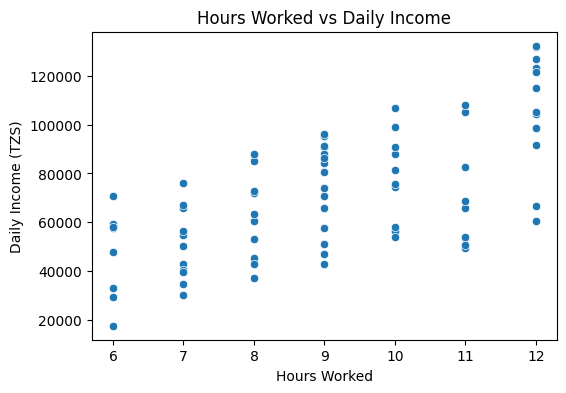

In [179]:
# Hours worked vs Income

plt.figure(figsize=(6,4))
sns.scatterplot(x='hours_worked', y='daily_income', data=df)
plt.title("Hours Worked vs Daily Income")
plt.xlabel("Hours Worked")
plt.ylabel("Daily Income (TZS)")
plt.show()

#“The scatter plot shows a clear upward trend: as the number of hours worked increases, 
#the daily income of a bodaboda rider also increases. This indicates a strong positive relationship between 
#working hours and earnings.”


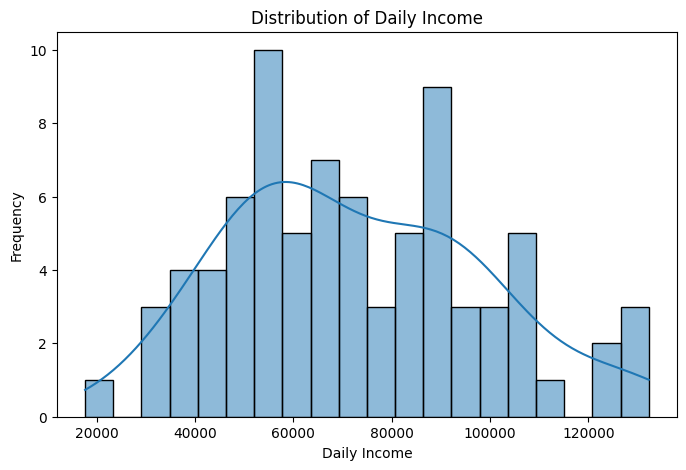

In [180]:
plt.figure(figsize=(8,5))
sns.histplot(df['daily_income'], bins=20, kde=True)
plt.title("Distribution of Daily Income")
plt.xlabel("Daily Income")
plt.ylabel("Frequency")
plt.show()
#Most riders earn around the center of the distribution,
#with fewer earning very low or very high income.


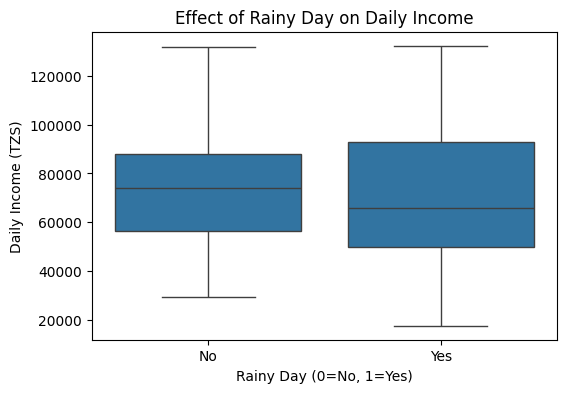

In [182]:
plt.figure(figsize=(6,4))
sns.boxplot(x='rainy_day', y='daily_income', data=df)
plt.title("Effect of Rainy Day on Daily Income")
plt.xlabel("Rainy Day (0=No, 1=Yes)")
plt.ylabel("Daily Income (TZS)")
plt.show()
#“The boxplot shows that on rainy days, the median daily income is lower than on non-rainy days. 
#This indicates that weather negatively affects earnings, likely because fewer customers ride during rain.”

In [183]:
#Saving the model
import joblib

joblib.dump(label_encoder,'label_encoder.pkl')

['label_encoder.pkl']

In [177]:
joblib.dump(onehot_encoder,'onehot_encoder.pkl')

['onehot_encoder.pkl']

In [149]:
joblib.dump(ordinal_encoder,'ordinal_encoder.pkl')

['ordinal_encoder.pkl']

In [150]:
#joblib.dump(regressorLR,'model.pkl')

In [185]:
joblib.dump(rf_model, "model.pkl")

['model.pkl']